# New technique Wise


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
from matplotlib.lines import Line2D

def plot_layer_metrics(
    file_path: str,
    project_name: str,
    layers: List[int],
    fisher_options: List[bool],
    module_types: List[str],
    title: str,
    ylabel: str,
    component: str,
    metric: str,
    output_file: str = None,
    smooth: bool = False,
    include_fisher_legend: bool = True,
    use_log_scale: bool = True
):
    # Load data
    df = pd.read_csv(file_path)
    x = df['Step']

    # Define styles
    colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']
    line_styles = {True: '--', False: '-'}  # Fisher: dashed, No Fisher: solid
    if not include_fisher_legend:
        line_styles = {True: '-', False: '-'}

    # Set up figure
    fig, ax = plt.subplots(figsize=(12, 8))
    layer_labels_added = set()

    for i, layer in enumerate(layers):
        for j, module in enumerate(module_types):
            for fisher in fisher_options:
                fisher_str = str(fisher).lower()
                col_name = f"layer_{layer}_{component}_{module}_fisher_{fisher_str}_project_{project_name} - {metric}"

                if col_name not in df.columns:
                    print(f"Warning: Missing column '{col_name}'")
                    continue

                y = df[col_name]
                if smooth:
                    y = y.rolling(window=10, min_periods=1).mean()

                # Label each layer only once
                # Only use label for the non-Fisher (solid) line
                if not fisher and layer not in layer_labels_added:
                    label = f"Layer {layer}"
                    layer_labels_added.add(layer)
                else:
                    label = None
                ax.plot(
                    x, y,
                    label=label,
                    color=colors[i % len(colors)],
                    linestyle=line_styles[fisher],
                    linewidth=2,
                    alpha=0.4 if not fisher else 1.0,
                )

    # Axis labels
    ax.set_title(title)
    ax.set_xlabel('Training Step')
    ax.set_ylabel(ylabel)
    if use_log_scale:
        ax.set_yscale('log')
    ax.grid(True, linestyle='--', linewidth=0.5)

    # Get handles for layer lines
    layer_handles, layer_labels = ax.get_legend_handles_labels()

    # Custom legend for Fisher line styles
    custom_lines = []
    if include_fisher_legend:
        custom_lines = [
            Line2D([0], [0], color='black', linestyle='-', label='No Fisher'),
            Line2D([0], [0], color='black', linestyle='--', label='Fisher')
        ]

    # Final legend: Fisher styles + layers
    ax.legend(
        handles=custom_lines + layer_handles,
        loc='upper left',
        fontsize='small',
        title='Legend'
    )

    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, bbox_inches='tight', format='pdf')
    plt.show()


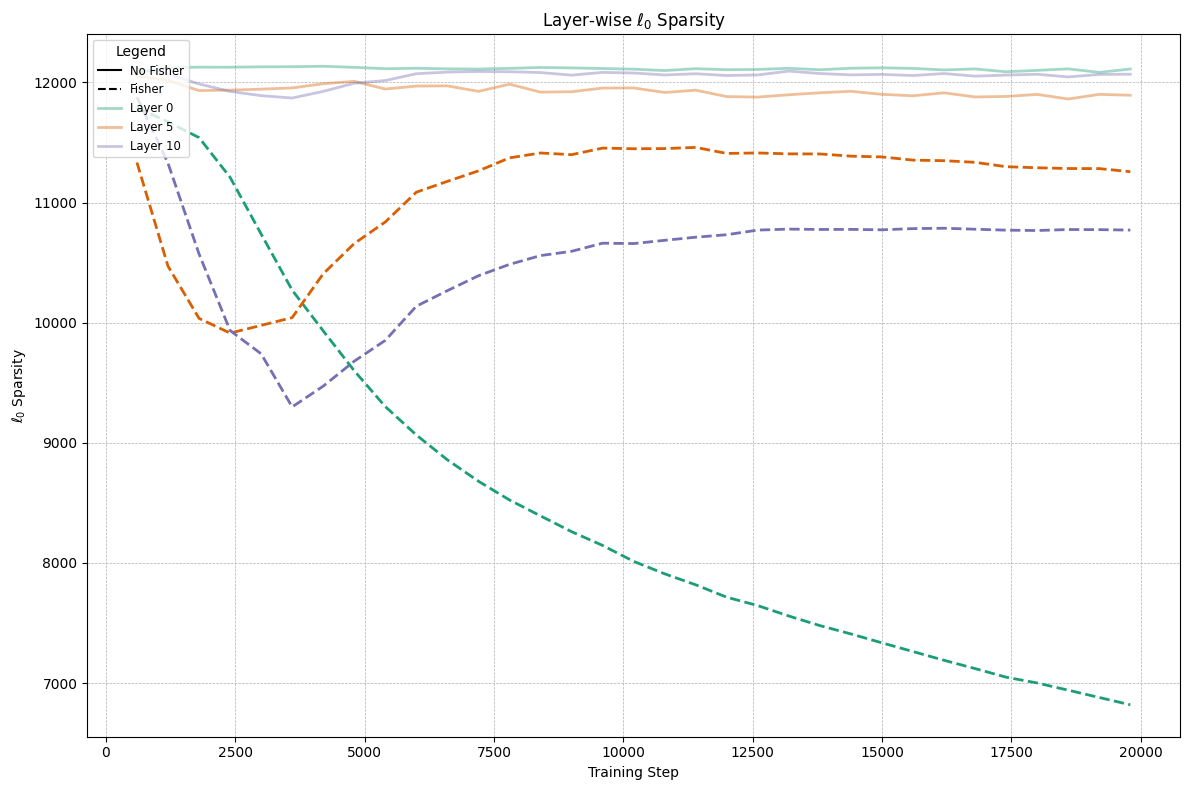

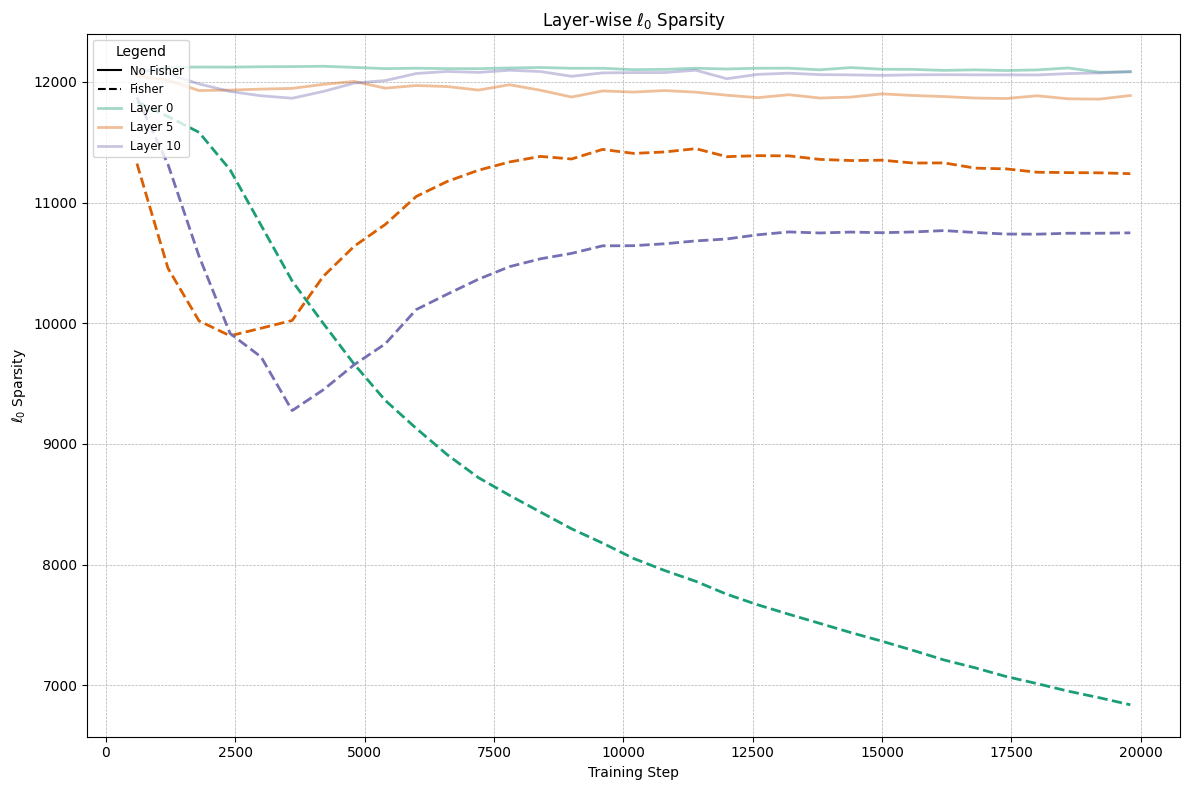

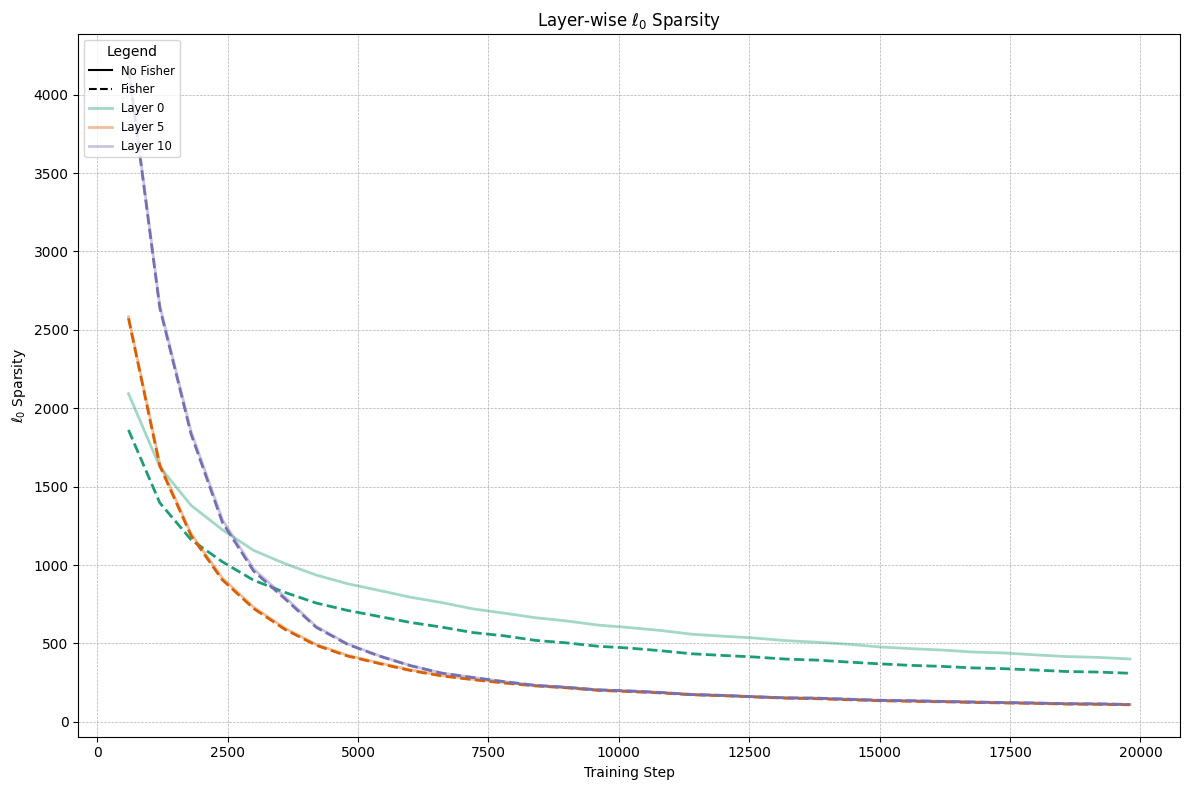

In [ ]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_standard_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_jumprelu_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_jumprelu_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_gated_l0_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_gated_l0_sparsity_plot.pdf',
    use_log_scale=False
)

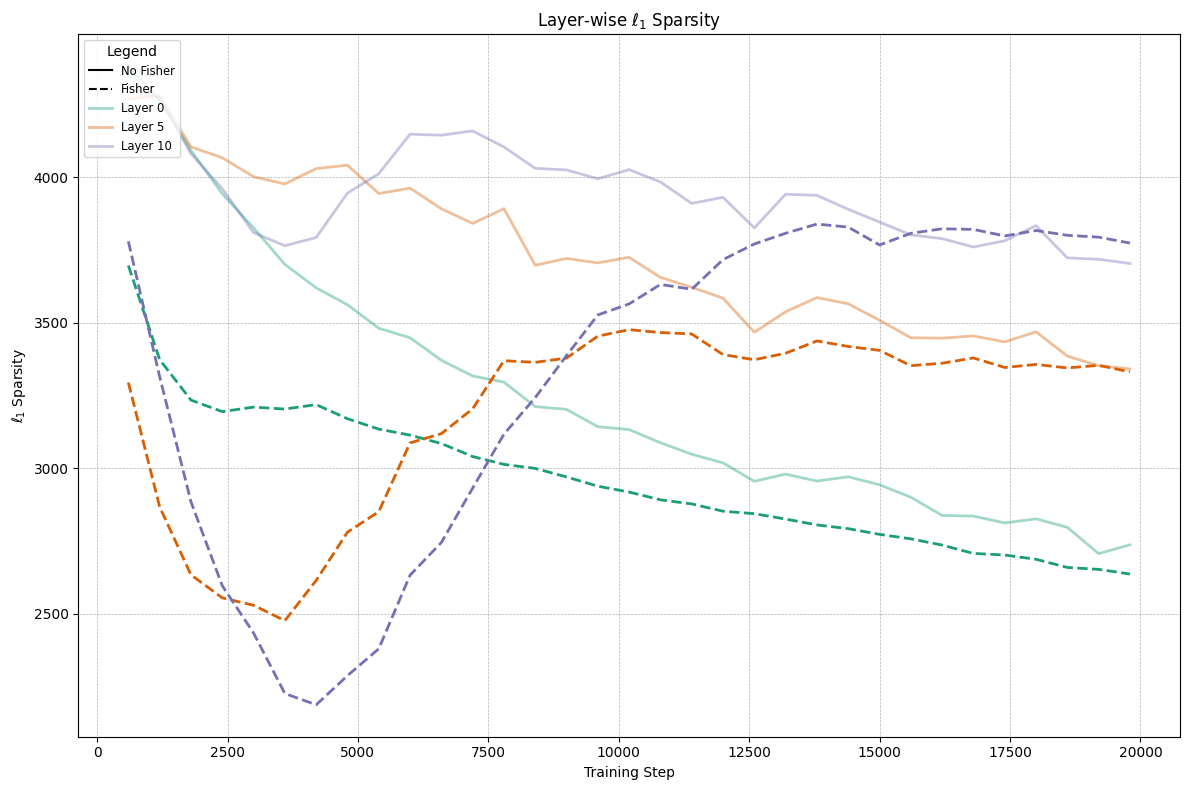

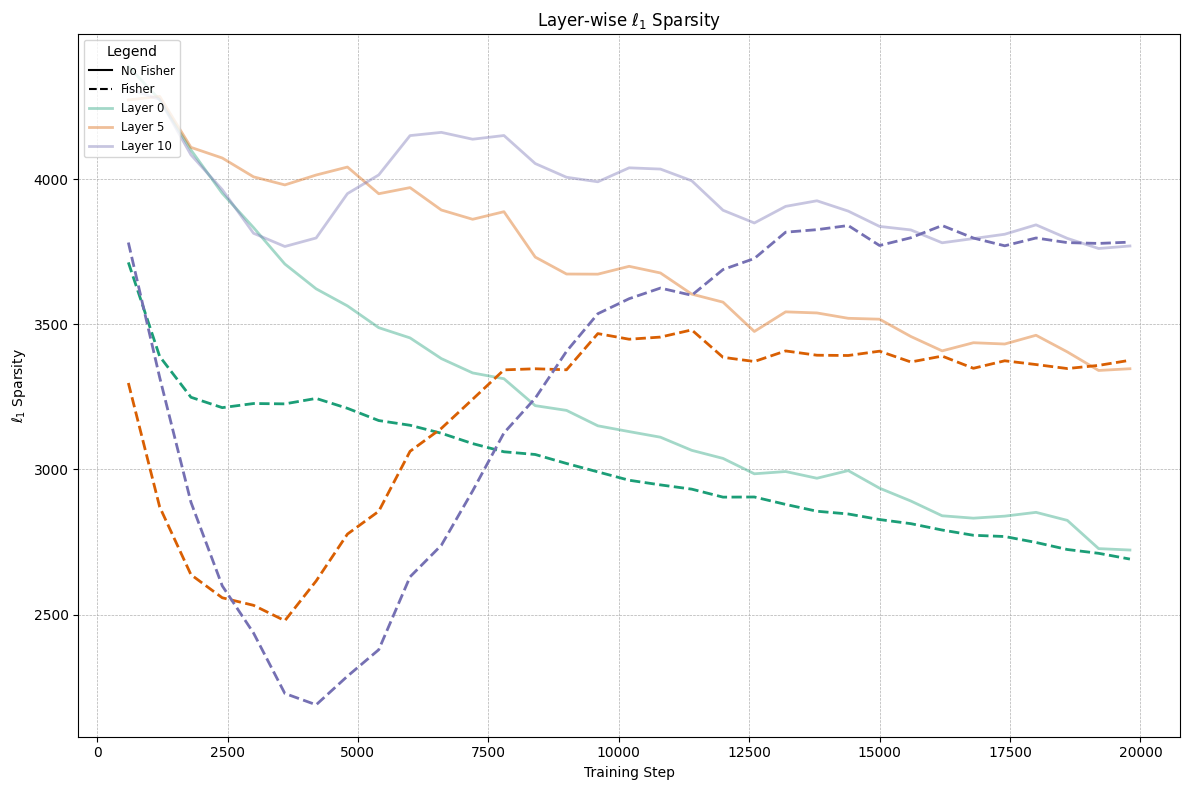

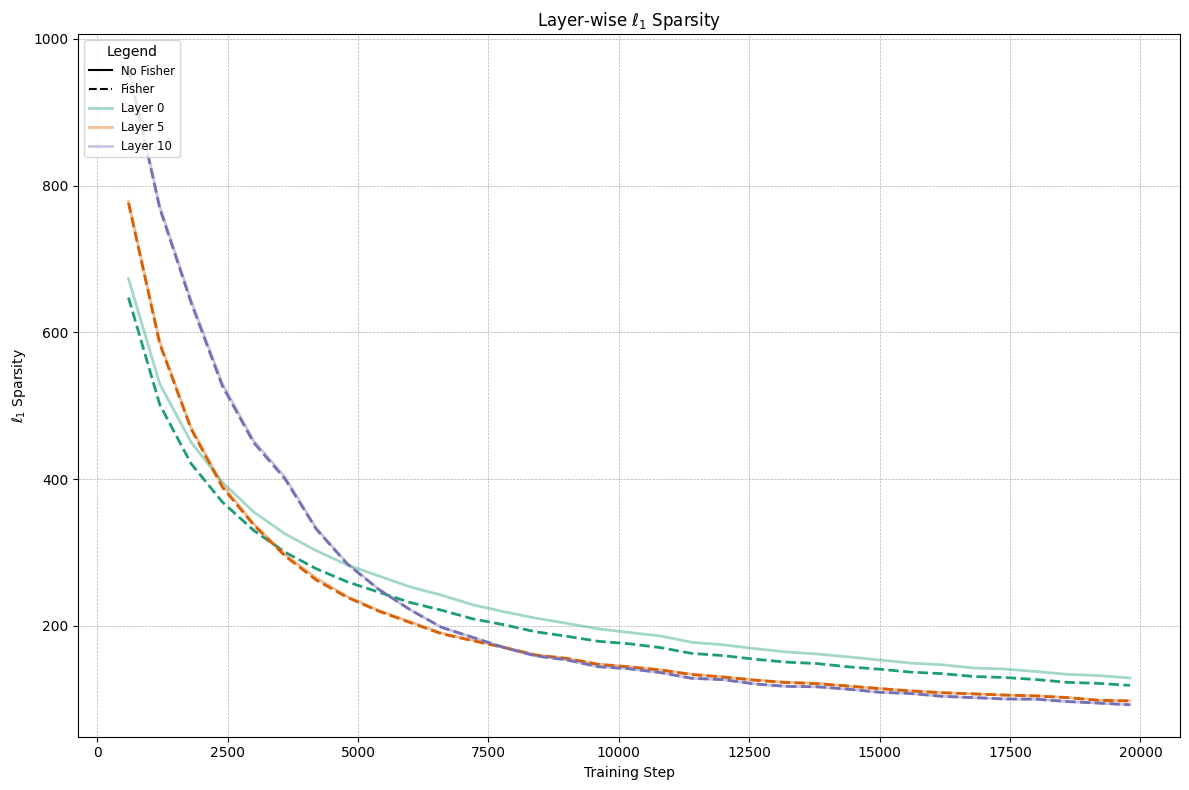

In [26]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_standard_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["standard"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_l1_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_jumprelu_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["jumprelu"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_jumprelu_l1_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_gated_l1_sparsity.csv',
    layers=[0, 5, 10],
    project_name='Devign',
    module_types=["gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_gated_l1_sparsity_plot.pdf',
    use_log_scale=False
)

# Dump

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import List
from matplotlib.lines import Line2D

def plot_layer_metrics(
    file_path: str,
    project_name: str,
    layers: List[int],
    fisher_options: List[bool],
    module_types: List[str],
    title: str,
    ylabel: str,
    component: str,
    metric: str,
    output_file: str = None,
    smooth: bool = False,
    include_fisher_legend: bool = True,
    use_log_scale: bool = True
):
    # Load data
    df = pd.read_csv(file_path)
    x = df['Step']

    # Define styles
    colors = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']
    line_styles = {True: '--', False: '-'}  # Fisher: dashed, No Fisher: solid
    if not include_fisher_legend:
        line_styles = {True: '-', False: '-'}  # Both Fisher and No Fisher as solid lines   

    # Set up subplots
    fig, axes = plt.subplots(nrows=len(layers), ncols=1, figsize=(10, 3 * len(layers)), sharex=True)
    if len(layers) == 1:
        axes = [axes]  # Ensure iterable

    for i, layer in enumerate(layers):
        ax: plt.Subplot = axes[i]
        plotted_labels = set()

        for j, module in enumerate(module_types):
            for fisher in fisher_options:
                fisher_str = str(fisher).lower()
                col_name = f"layer_{layer}_{component}_{module}_fisher_{fisher_str}_project_{project_name} - {metric}"

                if col_name not in df.columns:
                    print(f"Warning: Missing column '{col_name}'")
                    continue

                y = df[col_name]
                label = module
                plot_label = label if label not in plotted_labels else None
                if plot_label:
                    plotted_labels.add(label)
                
                if smooth:
                    y = y.rolling(window=10, min_periods=1).mean()

                ax.plot(
                    x, y,
                    label=plot_label,
                    color=colors[j % len(colors)],
                    linestyle=line_styles[fisher],
                    linewidth=2,
                    alpha=0.4 if not fisher else 1.0,
                )

        ax.set_ylabel(f"Layer {layer}\n{ylabel}")
        if use_log_scale:
            ax.set_yscale('log')
        ax.grid(True, linestyle='--', linewidth=0.5)
        if i == 0:
            ax.set_title(title)
        if i == len(layers) - 1:
            ax.set_xlabel('Training Step')

        # Add custom line style legend (only once)
        if i == 0:
            module_legend = ax.get_legend_handles_labels()
            if include_fisher_legend:
                # Custom legend for Fisher lines
                custom_lines = [
                    Line2D([0], [0], color='black', linestyle='-', label='No Fisher'),
                    Line2D([0], [0], color='black', linestyle='--', label='Fisher')
                ]
            else:
                custom_lines = []
            ax.legend(
                handles=custom_lines + module_legend[0],
                loc='upper left',
                fontsize='small',
                title='Fisher Options'
            )

    plt.tight_layout()
    if output_file:
        plt.savefig(output_file, bbox_inches='tight', format='pdf')
    plt.show()



## Devign

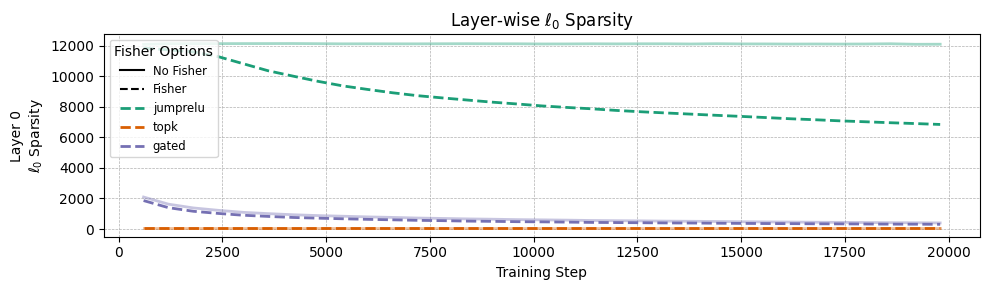

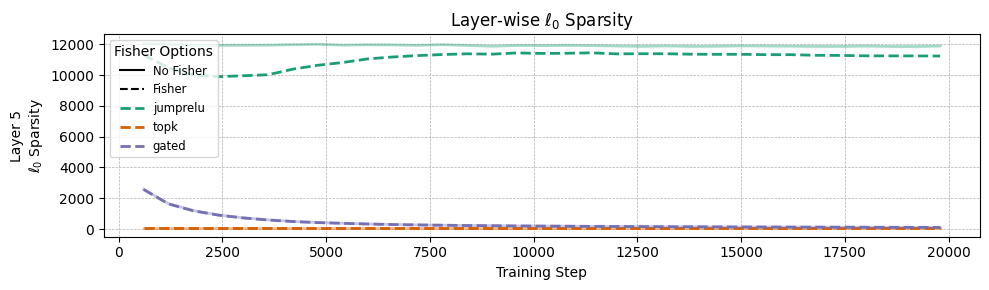

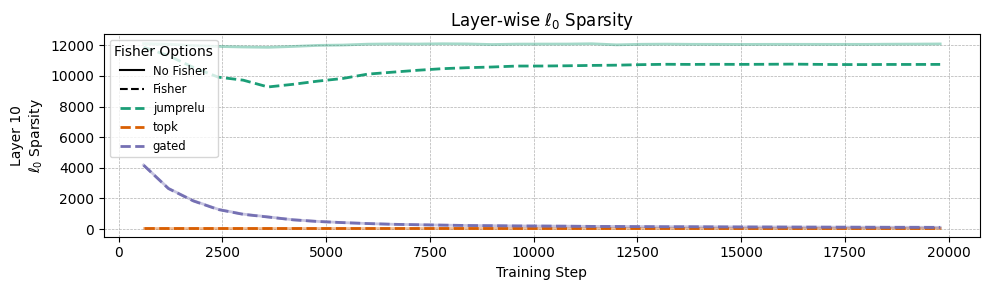

In [91]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l0_sparsity.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer0_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l0_sparsity.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer5_l0_sparsity_plot.pdf',
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l0_sparsity.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    metric='sparsity.l0',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer10_l0_sparsity_plot.pdf',
    use_log_scale=False
)

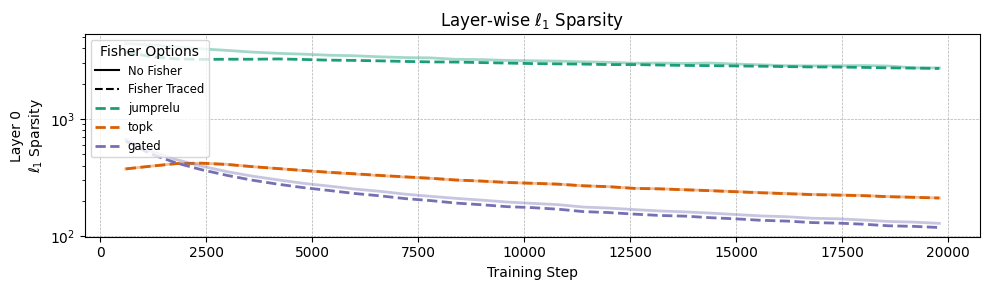

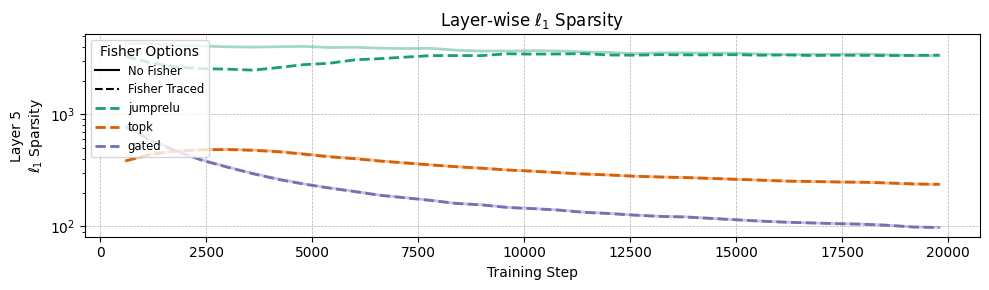

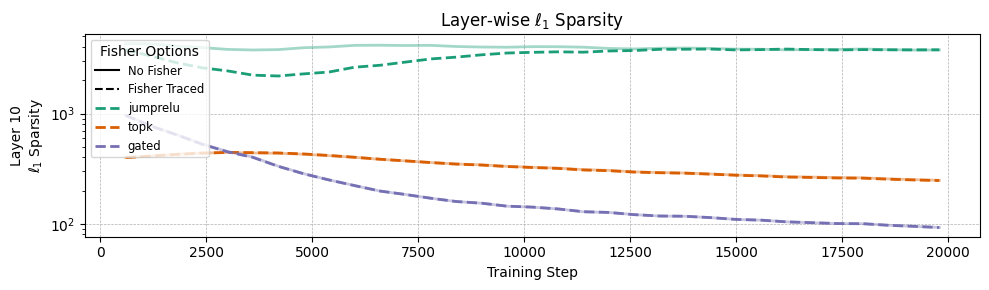

In [71]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l1_sparsity.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer0_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l1_sparsity.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer5_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l1_sparsity.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    metric='sparsity.l1',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer10_l1_sparsity_plot.pdf'
)

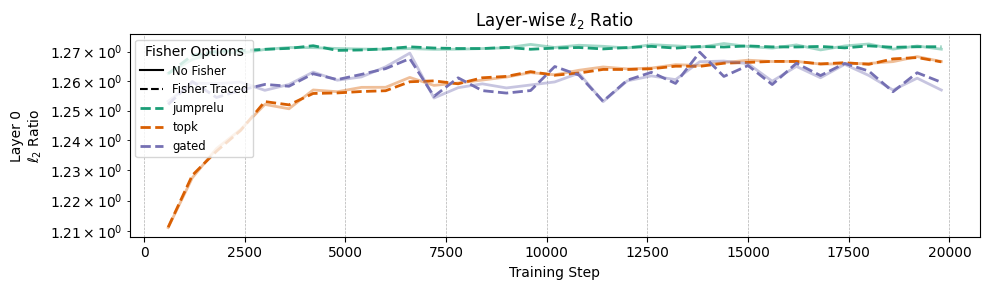

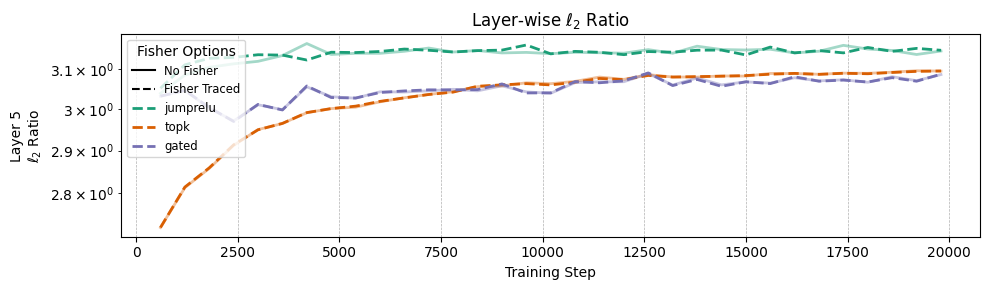

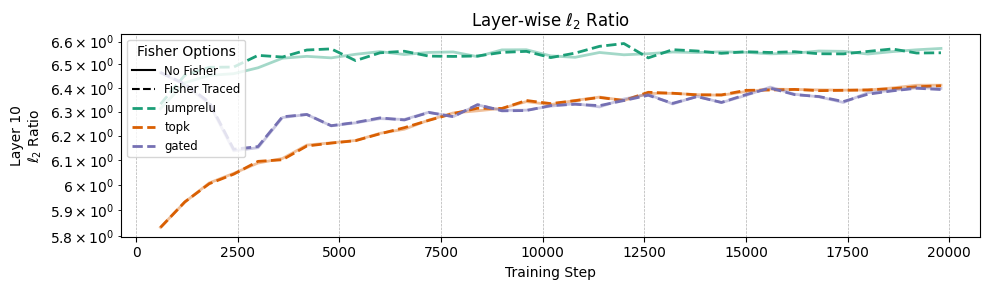

In [72]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_l2_ratio.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer0_l2_ratio_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_l2_ratio.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer5_l2_ratio_plot.pdf'
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_l2_ratio.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_2$ Ratio',
    ylabel='$\\ell_2$ Ratio',
    metric='shrinkage.l2_ratio',
    component='residual_mid_gpt2',
    output_file='Devign_residual_mid/layer10_l2_ratio_plot.pdf'
)

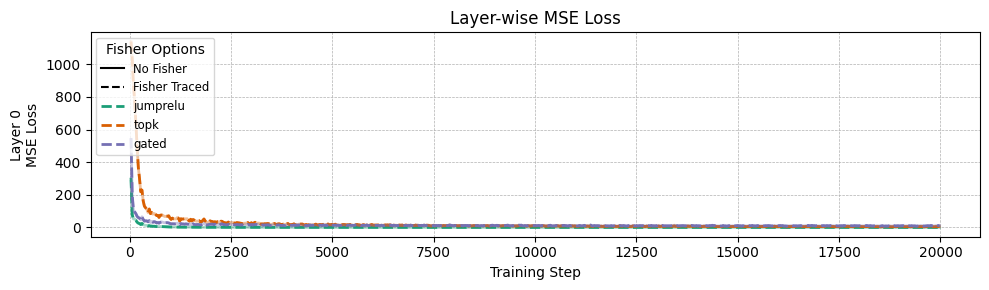

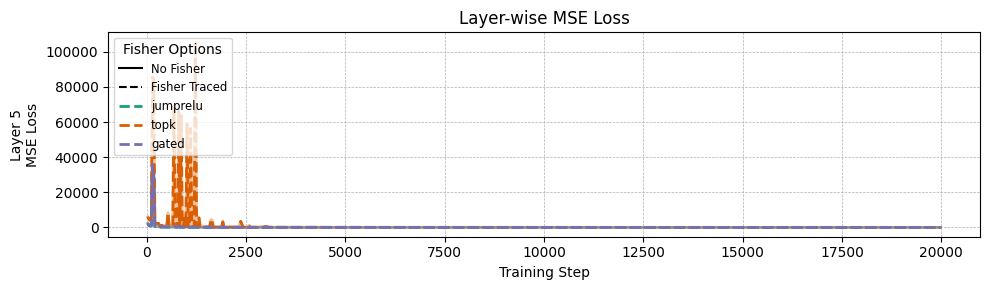

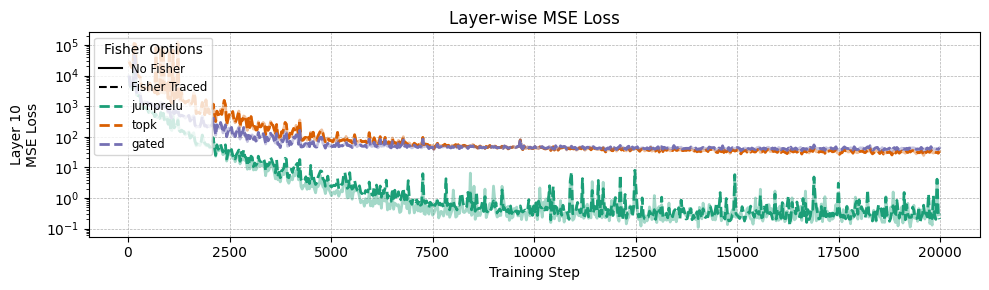

In [73]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_mse_loss.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_mse_loss_plot.pdf',
    # smooth=True,
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_mse_loss.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer5_mse_loss_plot.pdf',
    # smooth=True,
    use_log_scale=False
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_mse_loss.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise MSE Loss',
    ylabel='MSE Loss',
    metric='losses/mse_loss',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer10_mse_loss_plot.pdf',
    # smooth=True,
    # use_log_scale=False
)

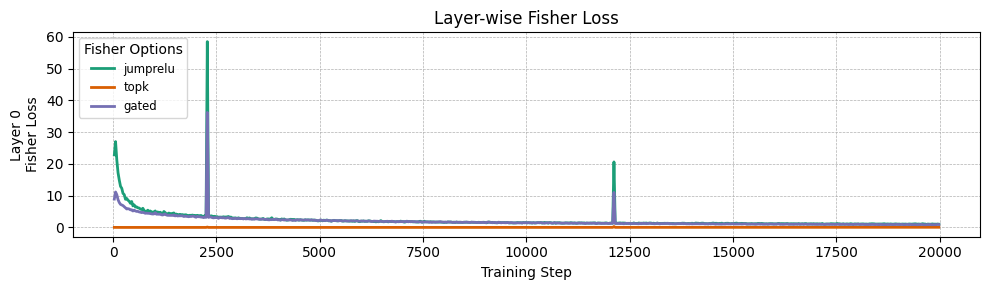

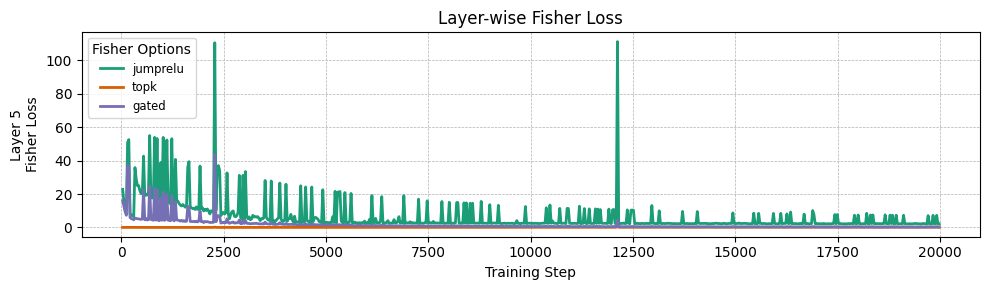

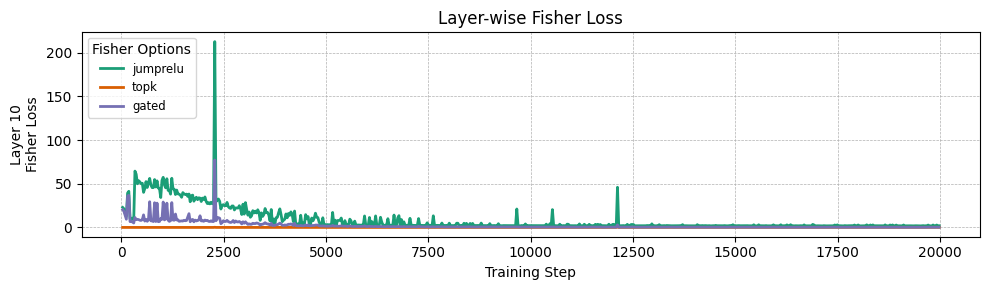

In [74]:
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_0_fisher_loss.csv',
    layers=[0],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer0_fisher_loss_plot.pdf',
    # smooth=True,
    include_fisher_legend=False,
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_5_fisher_loss.csv',
    layers=[5],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer5_fisher_loss_plot.pdf',
    # smooth=True,
    include_fisher_legend=False,
    use_log_scale=False,
)
plot_layer_metrics(
    file_path='Devign_residual_mid/Devign_residual_gpt_layer_10_fisher_loss.csv',
    layers=[10],
    project_name='Devign',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise Fisher Loss',
    ylabel='Fisher Loss',
    metric='losses/fisher_reg_term',
    component='hook_resid_mid_gpt2',
    output_file='Devign_residual_mid/layer10_fisher_loss_plot.pdf',
    # smooth=True,
    include_fisher_legend=False,
    use_log_scale=False,
)

## Tiny Stories

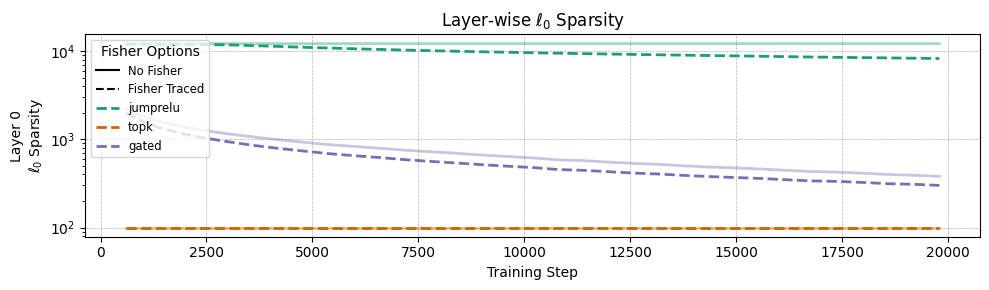

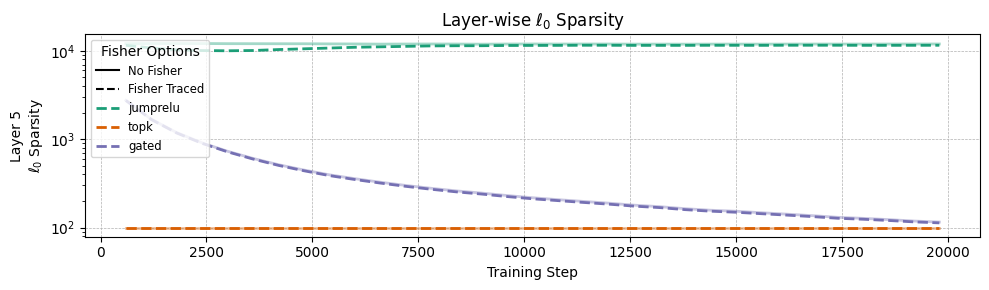

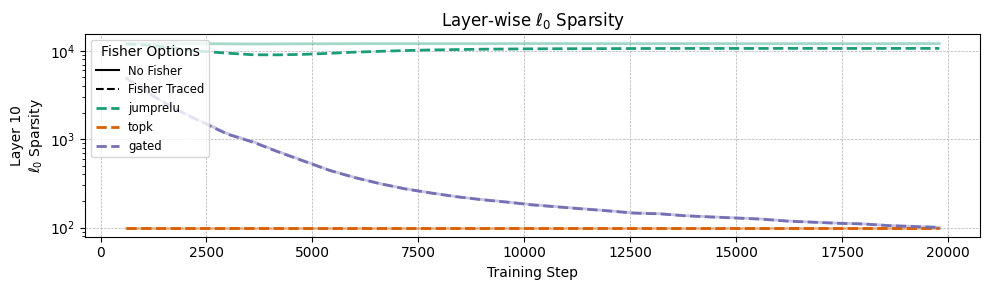

In [75]:
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_0_l0_sparsity.csv',
    layers=[0],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer0_l0_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_5_l0_sparsity.csv',
    layers=[5],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer_5_l0_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_10_l0_sparsity.csv',
    layers=[10],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_0$ Sparsity',
    ylabel='$\\ell_0$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l0',
    output_file='TinyStories_residual_mid/layer_10_l0_sparsity_plot.pdf'
)

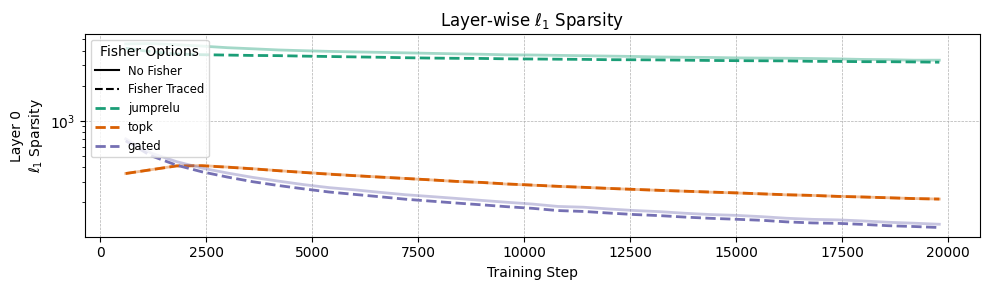

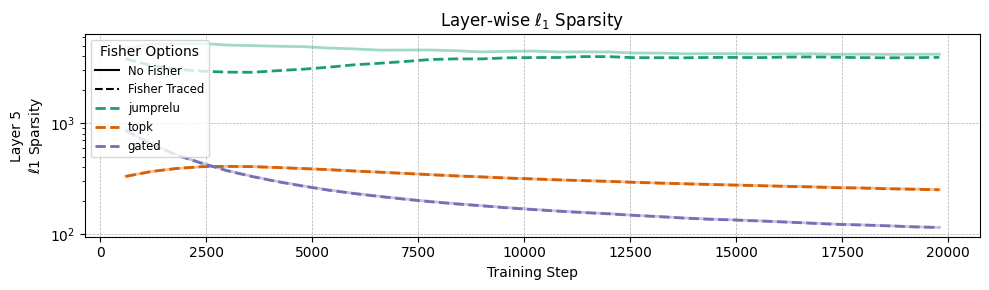

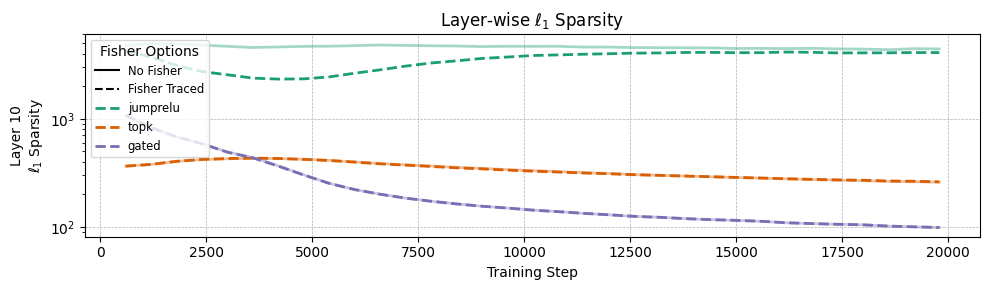

In [76]:
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_0_l1_sparsity.csv',
    layers=[0],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer0_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_5_l1_sparsity.csv',
    layers=[5],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell1$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer_5_l1_sparsity_plot.pdf'
)
plot_layer_metrics(
    file_path='TinyStories_residual_mid/TinyStories_residual_gpt_layer_10_l1_sparsity.csv',
    layers=[10],
    project_name='TinyStories',
    module_types=["jumprelu", "topk", "gated"],
    fisher_options=[True, False],
    title='Layer-wise $\\ell_1$ Sparsity',
    ylabel='$\\ell_1$ Sparsity',
    component='residual_mid_gpt2',
    metric='sparsity.l1',
    output_file='TinyStories_residual_mid/layer_10_l1_sparsity_plot.pdf'
)